# EDA comparatif - Gold shard 3

Comparaison entre:
- shards/gold_1k_shards/gold_shard_3.csv
- artifacts/gold_shard_3_cleaned/gold_shard_3.corrected.cleaned.csv

In [22]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

In [23]:
SOURCE_PATH = Path("shards/gold_1k_shards/gold_shard_3.csv")
CLEANED_PATH = Path("artifacts/gold_shard_3_cleaned/gold_shard_3.corrected.cleaned.csv")

def read_csv_smart(path: Path) -> pd.DataFrame:
    for enc in ("utf-8-sig", "utf-8", "latin1"):
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

def normalize_series(series: pd.Series) -> pd.Series:
    return (
        series.fillna("")
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

In [24]:
source_df = read_csv_smart(SOURCE_PATH)
cleaned_df = read_csv_smart(CLEANED_PATH)

print(f"Source file: {SOURCE_PATH}")
print(f"Cleaned file: {CLEANED_PATH}")
print(f"Source shape: {source_df.shape}")
print(f"Cleaned shape: {cleaned_df.shape}")

print("\nSource columns:")
print(source_df.columns.tolist())
print("\nCleaned columns:")
print(cleaned_df.columns.tolist())

Source file: shards\gold_1k_shards\gold_shard_3.csv
Cleaned file: artifacts\gold_shard_3_cleaned\gold_shard_3.corrected.cleaned.csv
Source shape: (1000, 9)
Cleaned shape: (979, 9)

Source columns:
['data_id', 'id', 'classe', 'darija_arabic', 'darija_arabizi', 'english', 'modern_standard_arabic', 'english_word_count', 'status']

Cleaned columns:
['data_id', 'id', 'classe', 'darija_arabic', 'darija_arabizi', 'english', 'modern_standard_arabic', 'english_word_count', 'status']


In [25]:
def summarize_dataset(df: pd.DataFrame, name: str) -> dict:
    summary = {
        "dataset": name,
        "rows": int(df.shape[0]),
        "columns": int(df.shape[1]),
        "duplicated_rows": int(df.duplicated().sum()),
    }
    if "data_id" in df.columns:
        summary["unique_data_id"] = int(df["data_id"].nunique(dropna=True))
        summary["duplicated_data_id"] = int(df["data_id"].duplicated().sum())
    else:
        summary["unique_data_id"] = np.nan
        summary["duplicated_data_id"] = np.nan
    return summary

summary_df = pd.DataFrame([
    summarize_dataset(source_df, "source"),
    summarize_dataset(cleaned_df, "cleaned"),
])
summary_df

,dataset,rows,columns,duplicated_rows,unique_data_id,duplicated_data_id
0,source,1000,9,0,1000,0
1,cleaned,979,9,0,979,0


In [26]:
common_cols = sorted(set(source_df.columns) & set(cleaned_df.columns))

missing_table = pd.DataFrame({
    "source_missing": source_df[common_cols].isna().sum(),
    "cleaned_missing": cleaned_df[common_cols].isna().sum(),
})
missing_table["delta_cleaned_minus_source"] = (
    missing_table["cleaned_missing"] - missing_table["source_missing"]
)

print("Missing values (top 20 by absolute delta):")
missing_table.assign(abs_delta=missing_table["delta_cleaned_minus_source"].abs())\
    .sort_values("abs_delta", ascending=False)\
    .drop(columns=["abs_delta"])\
    .head(20)

def status_counts(df: pd.DataFrame, name: str) -> pd.Series:
    if "status" not in df.columns:
        return pd.Series(dtype="int64", name=name)
    s = df["status"].fillna("<NA>").astype(str).value_counts(dropna=False)
    s.name = name
    return s

status_table = pd.concat(
    [status_counts(source_df, "source"), status_counts(cleaned_df, "cleaned")],
    axis=1,
).fillna(0).astype(int)

if not status_table.empty:
    print("\nStatus distribution:")
    display(status_table)
else:
    print("\nStatus column is not present in one or both datasets.")

Missing values (top 20 by absolute delta):

Status distribution:


,source,cleaned
status,,
GENERATED,749,354
PARTIALLY VALIDATED,250,127
active,1,0
VALIDATED,0,498


In [27]:
if "data_id" in source_df.columns and "data_id" in cleaned_df.columns:
    source_ids = set(source_df["data_id"].dropna().astype(str))
    cleaned_ids = set(cleaned_df["data_id"].dropna().astype(str))

    overlap_df = pd.DataFrame({
        "metric": [
            "source_unique_ids",
            "cleaned_unique_ids",
            "intersection_ids",
            "source_only_ids",
            "cleaned_only_ids",
        ],
        "count": [
            len(source_ids),
            len(cleaned_ids),
            len(source_ids & cleaned_ids),
            len(source_ids - cleaned_ids),
            len(cleaned_ids - source_ids),
        ],
    })
    overlap_df
else:
    print("No data_id in one or both datasets; overlap cannot be computed.")

Comparable text columns: ['darija_arabic', 'darija_arabizi', 'english', 'modern_standard_arabic']


,dataset,column,mean_len,median_len,p95_len,max_len
0,source,darija_arabic,129.553000,129.0,238.05,3739
1,source,darija_arabizi,136.088000,139.0,257.00,333
2,source,english,146.487000,152.0,266.05,566
3,source,modern_standard_arabic,123.551000,127.0,234.00,335
4,cleaned,darija_arabic,102.901941,104.0,207.10,524
5,cleaned,darija_arabizi,114.407559,114.0,223.20,307
6,cleaned,english,101.013279,103.0,197.00,412
7,cleaned,modern_standard_arabic,95.116445,98.0,192.00,261


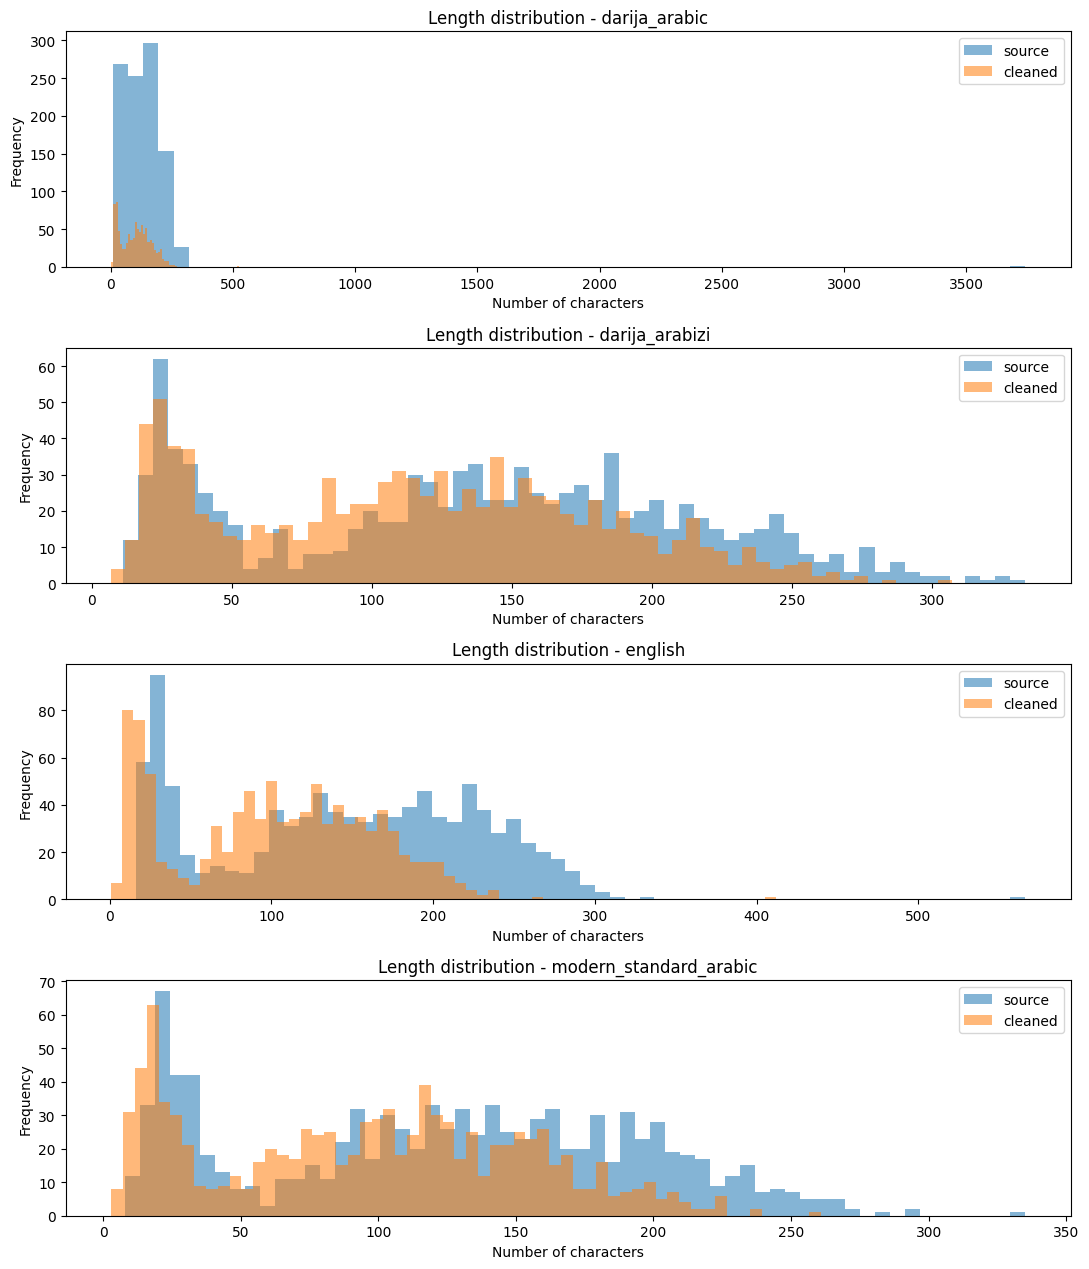

In [28]:
TEXT_COLS = [
    col
    for col in ["darija_arabic", "darija_arabizi", "english", "modern_standard_arabic"]
    if col in source_df.columns and col in cleaned_df.columns
]
print("Comparable text columns:", TEXT_COLS)

def length_stats(df: pd.DataFrame, dataset_name: str, cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in cols:
        lengths = df[col].fillna("").astype(str).str.len()
        rows.append({
            "dataset": dataset_name,
            "column": col,
            "mean_len": float(lengths.mean()),
            "median_len": float(lengths.median()),
            "p95_len": float(lengths.quantile(0.95)),
            "max_len": int(lengths.max() if len(lengths) else 0),
        })
    return pd.DataFrame(rows)

if TEXT_COLS:
    length_df = pd.concat([
        length_stats(source_df, "source", TEXT_COLS),
        length_stats(cleaned_df, "cleaned", TEXT_COLS),
    ], ignore_index=True)
    display(length_df)

    fig, axes = plt.subplots(len(TEXT_COLS), 1, figsize=(11, 3.2 * len(TEXT_COLS)))
    if len(TEXT_COLS) == 1:
        axes = [axes]

    for ax, col in zip(axes, TEXT_COLS):
        source_df[col].fillna("").astype(str).str.len().plot(
            kind="hist", bins=60, alpha=0.55, label="source", ax=ax
        )
        cleaned_df[col].fillna("").astype(str).str.len().plot(
            kind="hist", bins=60, alpha=0.55, label="cleaned", ax=ax
        )
        ax.set_title(f"Length distribution - {col}")
        ax.set_xlabel("Number of characters")
        ax.legend()

    plt.tight_layout()
else:
    print("No common text columns to compare.")

In [29]:
comp = None
join_key = "data_id"

if not TEXT_COLS:
    print("No comparable text columns for diff analysis.")
elif "data_id" in source_df.columns and "data_id" in cleaned_df.columns:
    source_cmp = source_df[["data_id"] + TEXT_COLS].drop_duplicates(subset="data_id", keep="first")
    cleaned_cmp = cleaned_df[["data_id"] + TEXT_COLS].drop_duplicates(subset="data_id", keep="first")
    comp = source_cmp.merge(cleaned_cmp, on="data_id", how="inner", suffixes=("_source", "_cleaned"))
else:
    join_key = "row_index"
    src = source_df[TEXT_COLS].reset_index(drop=True)
    cln = cleaned_df[TEXT_COLS].reset_index(drop=True)
    n = min(len(src), len(cln))
    comp = pd.DataFrame({"row_index": range(n)})
    for col in TEXT_COLS:
        comp[f"{col}_source"] = src[col].iloc[:n].values
        comp[f"{col}_cleaned"] = cln[col].iloc[:n].values

if comp is not None and not comp.empty:
    for col in TEXT_COLS:
        left = normalize_series(comp[f"{col}_source"])
        right = normalize_series(comp[f"{col}_cleaned"])
        comp[f"{col}_changed"] = left.ne(right)

    changes = []
    for col in TEXT_COLS:
        changed_count = int(comp[f"{col}_changed"].sum())
        total = int(len(comp))
        pct = (changed_count / total * 100.0) if total else 0.0
        changes.append({
            "column": col,
            "compared_rows": total,
            "changed_rows": changed_count,
            "change_rate_pct": round(pct, 2),
        })

    change_df = pd.DataFrame(changes).sort_values("change_rate_pct", ascending=False)
    display(change_df)

    overall_changed = int(comp[[f"{col}_changed" for col in TEXT_COLS]].any(axis=1).sum())
    print(f"Rows with at least one changed text field: {overall_changed}/{len(comp)}")
else:
    print("No overlapping rows found for text diff analysis.")

,column,compared_rows,changed_rows,change_rate_pct
2,english,979,979,100.00
0,darija_arabic,979,972,99.28
3,modern_standard_arabic,979,969,98.98
1,darija_arabizi,979,905,92.44


Rows with at least one changed text field: 979/979


In [30]:
if comp is None or comp.empty:
    print("No comparable rows to preview.")
else:
    row_changed = comp[[f"{col}_changed" for col in TEXT_COLS]].any(axis=1)
    changed_preview = comp.loc[row_changed].copy()

    print(f"Comparable rows: {len(comp)}")
    print(f"Rows changed in >=1 text column: {len(changed_preview)}")

    preview_cols = [join_key]
    for col in TEXT_COLS:
        preview_cols += [f"{col}_source", f"{col}_cleaned", f"{col}_changed"]

    display(changed_preview[preview_cols].head(20))

Comparable rows: 979
Rows changed in >=1 text column: 979


,data_id,darija_arabic_source,darija_arabic_cleaned,darija_arabic_changed,darija_arabizi_source,darija_arabizi_cleaned,darija_arabizi_changed,english_source,english_cleaned,english_changed,modern_standard_arabic_source,modern_standard_arabic_cleaned,modern_standard_arabic_changed
0,data52034,فشيتلاند كيستعملو واحد الشكل آخر ديال الراية (...,فشىتلاند كىستعملو واحد الشكل اخر الراىه غراب ك...,True,f shetland kist3mlo wa7d chekel akhor dyal rra...,shetland kist3mlo wa7d chekel akhor rraya ghra...,True,In Shetland an alternate form of the banner ( ...,shetland alternate form banner black raven rec...,True,في شتلاند، يُستخدم شكل آخر للعلم (غراب أسود عل...,شتلاند يستخدم شكل اخر للعلم غراب اسود حقل احمر...,True
1,data52035,لحكومات لفيدرالية جوج مرات قتارحات باش يتبدل ل...,لحكومات لفىدرالىه جوج مرات قتارحات ىتبدل لماده...,True,l7kumamt lfederaliya joj mrat qtar7at bach ytb...,l7kumamt lfederaliya joj mrat qtar7at bach ytb...,True,Federal Governments have twice proposed the am...,federal governments twice proposed amendment s...,True,اقترحت الحكومات الفيدرالية مرتين تعديل المادة ...,اقترحت الحكومات الفيدرالية مرتين تعديل المادة ...,True
2,data52036,التصوير بدا ف أستراليا ف 7 دجنبر 2013، قبل ما ...,التصوىر بدا استرالىا دجنبر قبل ىتنقل للمملكه ا...,True,"tstowir bda f australia f 7 dechmbre 2013, qbe...",tstowir bda australia dechmbre qbel ytnqel mam...,True,Filming began in Australia on 7 December 2013 ...,filming began australia 7 december 2013 moving...,True,بدأ التصوير في أستراليا في 7 ديسمبر 2013، قبل ...,بدا التصوير استراليا الانتقال المملكة المتحدة ...,True
3,data52037,الصبغة اللي مبدلة اللون اللي كاينة فالرقم اللي...,الصبغه اللى مبدله اللون اللى كاىنه فالرقم اللى...,True,essabgha lli mbaddla llon lli kayna ferrqm lli...,essabgha lli mbaddla llon lli kayna ferrqm lli...,True,Colour changing ink used on the numeral locate...,colour changing ink used numeral located back ...,True,الحبر المتغير اللون المستخدم على الرقم الموجود...,الحبر المتغير اللون المستخدم الرقم الموجود ظهر...,True
4,data52038,المنتخب الألماني ماكانش محظوظ بزاف، خسر الفينا...,المنتخب الالمانى ماكانش محظوظ بزاف خسر الفىنال...,True,"al mountakhab al almani makanch mahdoud bzzaf,...",al mountakhab al almani makanch mahdoud bzzaf ...,True,The German national team was not so fortunate ...,german national team fortunate losing final eu...,True,لم يحالف المنتخب الألماني الحظ كثيرًا، حيث خسر...,يحالف المنتخب الالماني الحظ خسر نهائي بطولة او...,True
5,data52039,المرا ديال الحمالة يقدروا يوقعوا إلا كانت السل...,المرا الحماله ىقدروا ىوقعوا الا كانت السلىاك ك...,True,lmra dyal l7mala y9deru ywe93u ila kanet selia...,lmra l7mala y9deru ywe93u kanet seliak kayna f...,True,Pregnancy complications can occur in case of c...,pregnancy complications occur case coeliac dis...,True,يمكن أن تحدث مضاعفات الحمل في حالة الإصابة بمر...,يمكن تحدث مضاعفات الحمل حالة الاصابة بمرض الاض...,True
6,data52040,الوجود الجغرافي ديال هاد الفطر كاينة ف شمال أم...,الوجود الجغرافى الفطر كاىنه شمال امرىكا شمال ا...,True,lwjud l-jiyrafi dyal had l-fiytr kayn f shmal ...,lwjud jiyrafi had fiytr kayn shmal amrika shma...,True,The geographical distribution of the fungus in...,geographical distribution fungus includes nort...,True,يشمل التوزيع الجغرافي للفطر أمريكا الشمالية شم...,يشمل التوزيع الجغرافي للفطر امريكا الشمالية ال...,True
7,data52041,زيد عليها، هاد لپوليوم لي كتشرب حسن فالتعطية، ...,زىد علىها ل ولىوم لى كتشرب حسن فالتعطىه حىت مك...,True,"zid 3liha, had lpoliom li katchreb 7ssen fta3t...",zid 3liha had lpoliom li katchreb 7ssen fta3ti...,True,OPV also proved to be superior in administrati...,opv also proved superior administration elimin...,True,أثبت لقاح شلل الأطفال الفموي أيضًا تفوقه في ال...,اثبت لقاح شلل الاطفال الفموي تفوقه الاعطاء يلغ...,True
8,data52042,روميشا خرج من الجيش ف 2011 باش يدوز وقت كتر مع...,رومىشا خرج الجىش ىدوز وقت كتر عائلتو بعد شد خد...,True,romisha khrej men l-jiche f 2011 bach idawaz w...,romisha khrej jiche bach idawaz waqt ktar 3a2e...,True,Romesha left the Army in 2011 to sp

## Visualisations additionnelles

- Dashboard comparatif: volumetrie, statuts, classes, longueurs moyennes
- Analyse detaillee: boxplots, histogrammes, taux de changement

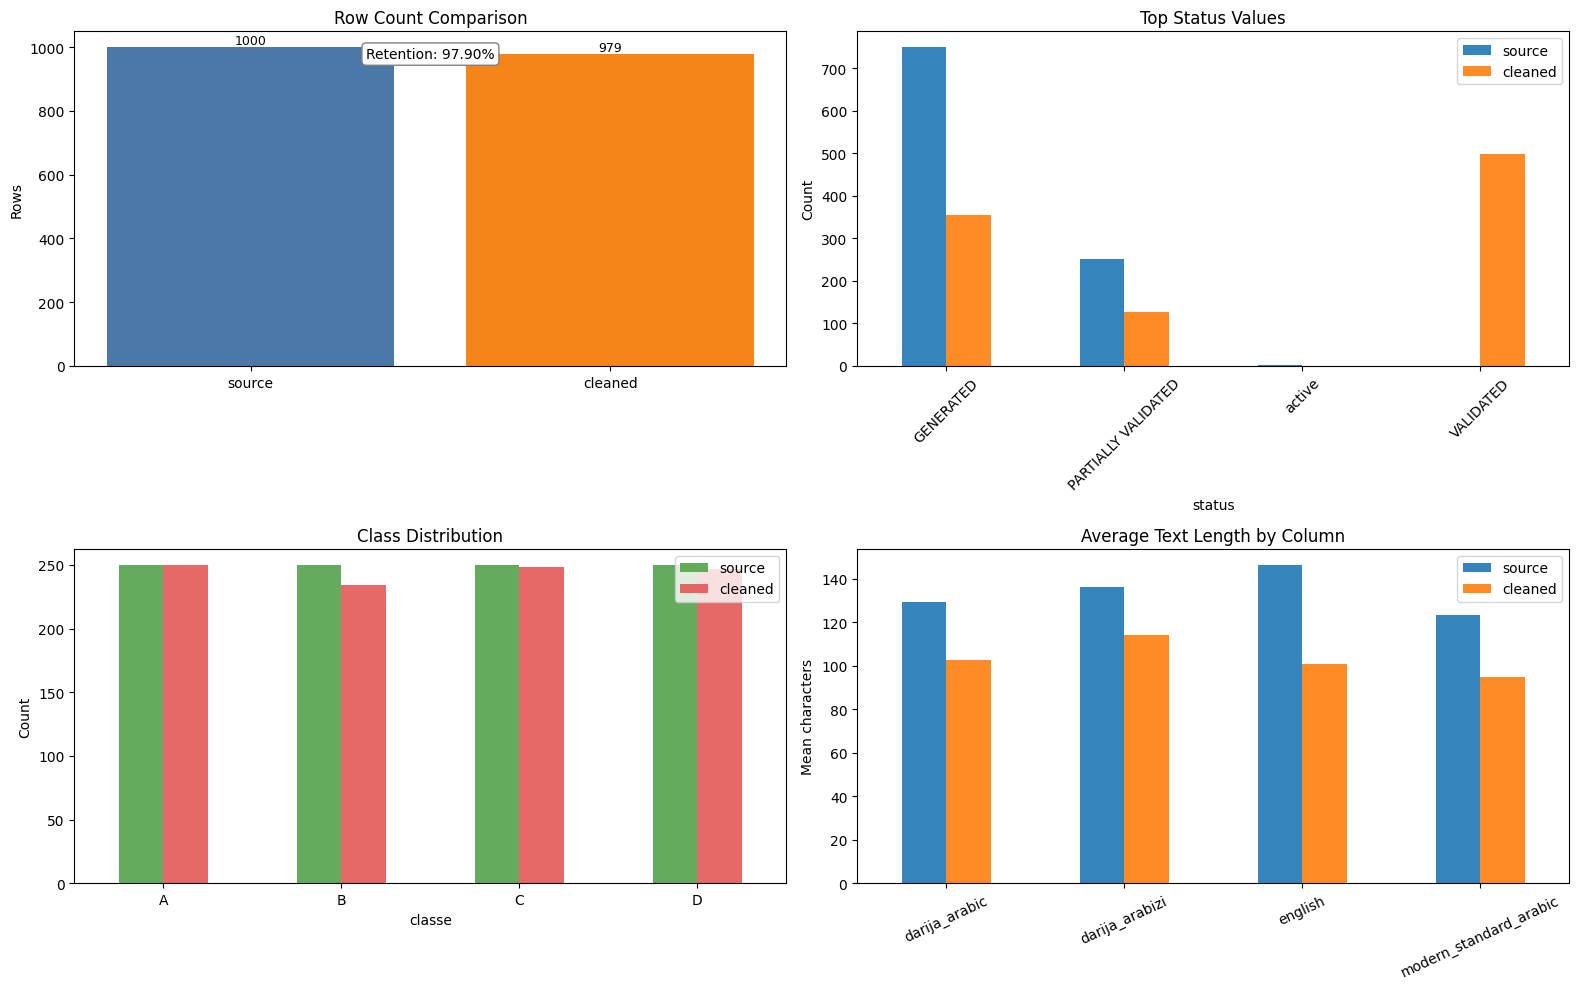

In [31]:
# Visual dashboard: volume, status, class, and average length
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

row_counts = pd.Series({'source': len(source_df), 'cleaned': len(cleaned_df)})
bars = axes[0].bar(row_counts.index, row_counts.values, color=['#4C78A8', '#F58518'])
axes[0].set_title('Row Count Comparison')
axes[0].set_ylabel('Rows')
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(bar.get_height())}',
        ha='center',
        va='bottom',
        fontsize=9,
    )
retention = (len(cleaned_df) / len(source_df) * 100.0) if len(source_df) else np.nan
axes[0].text(
    0.5,
    0.92,
    f'Retention: {retention:.2f}%',
    transform=axes[0].transAxes,
    ha='center',
    bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'),
)

if 'status' in source_df.columns and 'status' in cleaned_df.columns:
    src_status = source_df['status'].fillna('<NA>').astype(str).value_counts()
    cln_status = cleaned_df['status'].fillna('<NA>').astype(str).value_counts()
    status_comp = pd.concat(
        [src_status.rename('source'), cln_status.rename('cleaned')], axis=1
    ).fillna(0)
    status_comp = status_comp.sort_values('source', ascending=False).head(12)
    status_comp.plot(kind='bar', ax=axes[1], alpha=0.9)
    axes[1].set_title('Top Status Values')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].axis('off')
    axes[1].text(0.5, 0.5, 'Status column not found', ha='center', va='center')

if 'classe' in source_df.columns and 'classe' in cleaned_df.columns:
    src_class = source_df['classe'].fillna('<NA>').astype(str).value_counts()
    cln_class = cleaned_df['classe'].fillna('<NA>').astype(str).value_counts()
    class_comp = pd.concat(
        [src_class.rename('source'), cln_class.rename('cleaned')], axis=1
    ).fillna(0)
    class_comp = class_comp.sort_index()
    class_comp.plot(kind='bar', ax=axes[2], alpha=0.9, color=['#54A24B', '#E45756'])
    axes[2].set_title('Class Distribution')
    axes[2].set_ylabel('Count')
    axes[2].tick_params(axis='x', rotation=0)
else:
    axes[2].axis('off')
    axes[2].text(0.5, 0.5, 'Classe column not found', ha='center', va='center')

if TEXT_COLS:
    mean_len = pd.DataFrame(
        {
            'source': [source_df[c].fillna('').astype(str).str.len().mean() for c in TEXT_COLS],
            'cleaned': [cleaned_df[c].fillna('').astype(str).str.len().mean() for c in TEXT_COLS],
        },
        index=TEXT_COLS,
    )
    mean_len.plot(kind='bar', ax=axes[3], alpha=0.9)
    axes[3].set_title('Average Text Length by Column')
    axes[3].set_ylabel('Mean characters')
    axes[3].tick_params(axis='x', rotation=25)
else:
    axes[3].axis('off')
    axes[3].text(0.5, 0.5, 'No common text columns', ha='center', va='center')

plt.tight_layout()

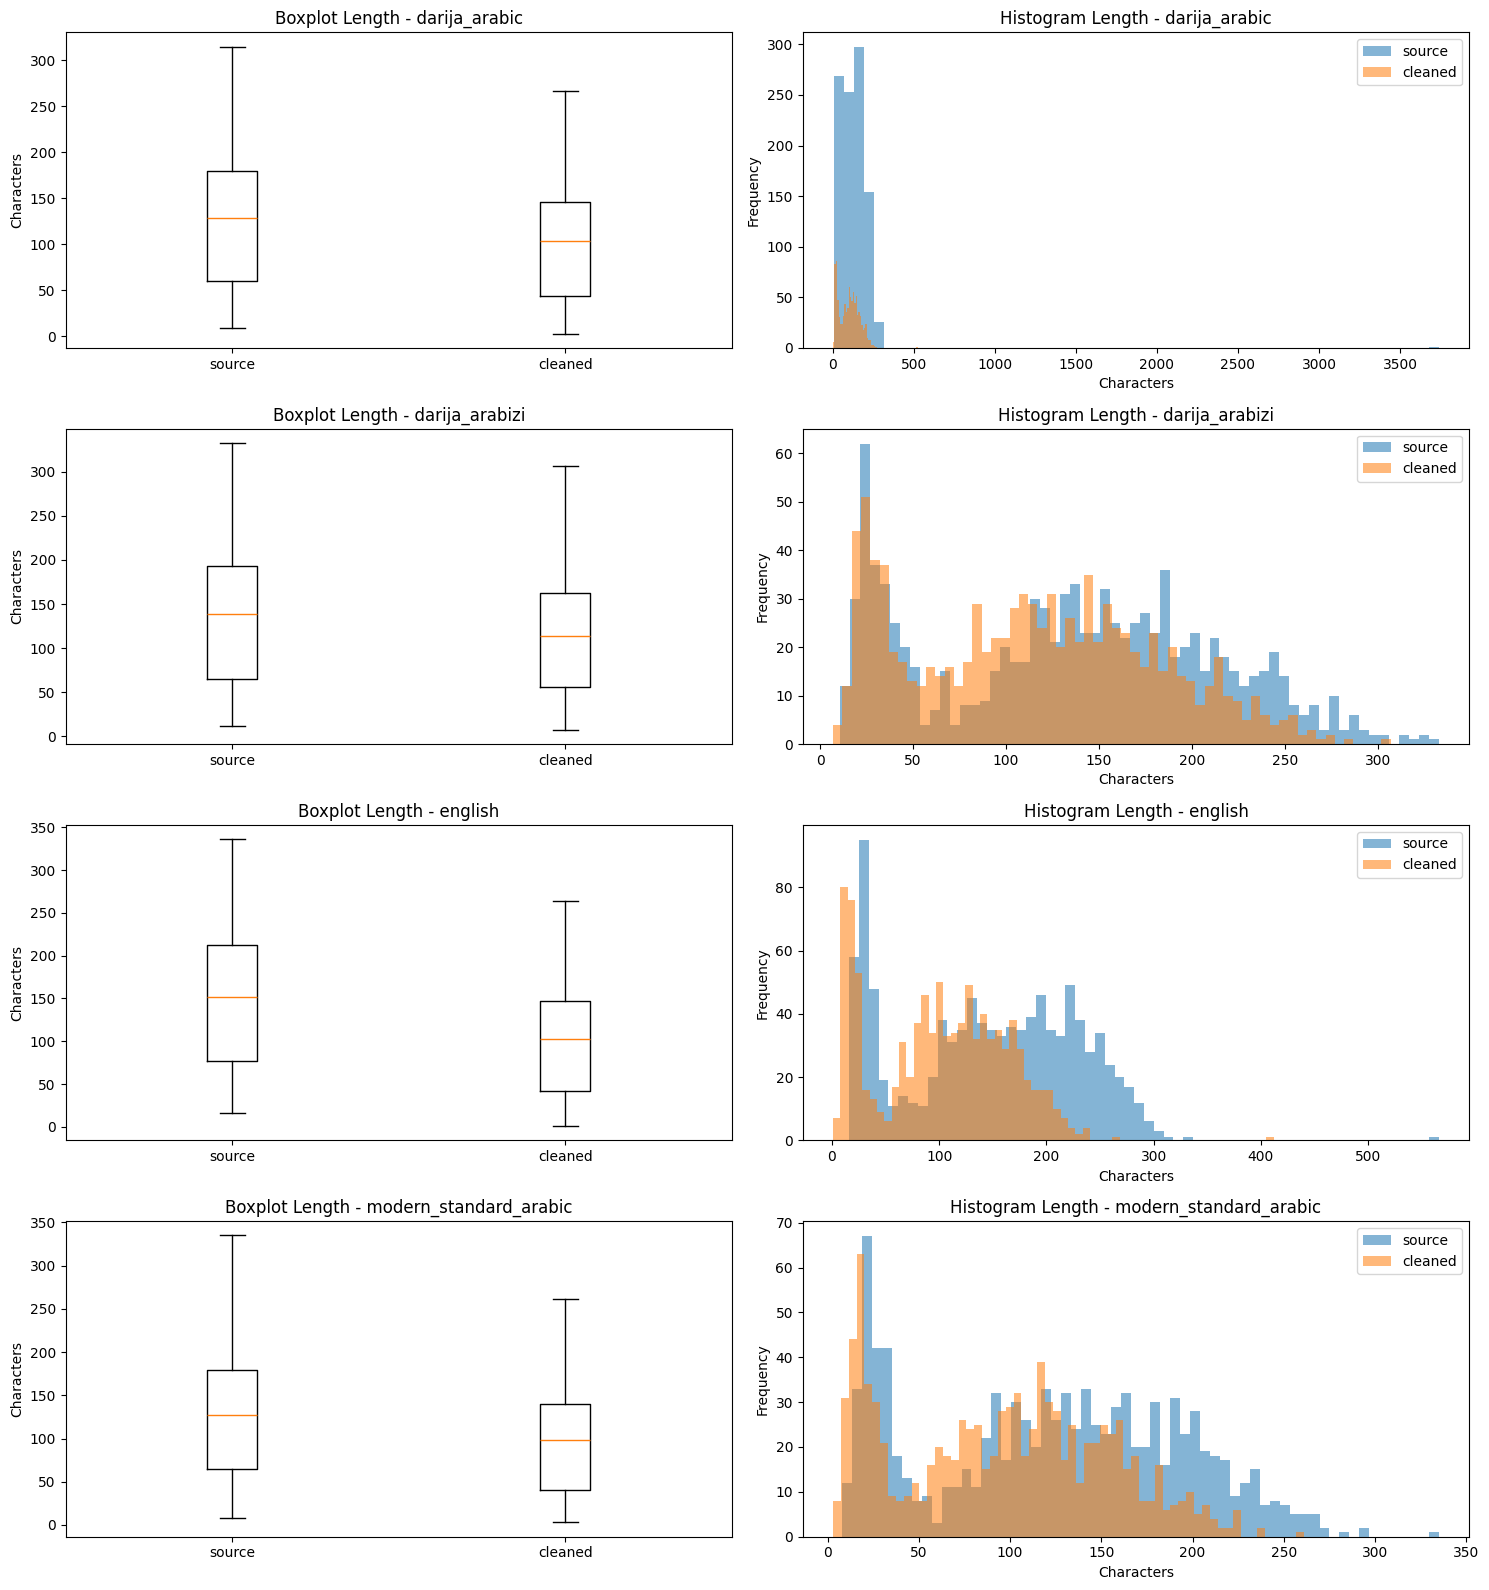

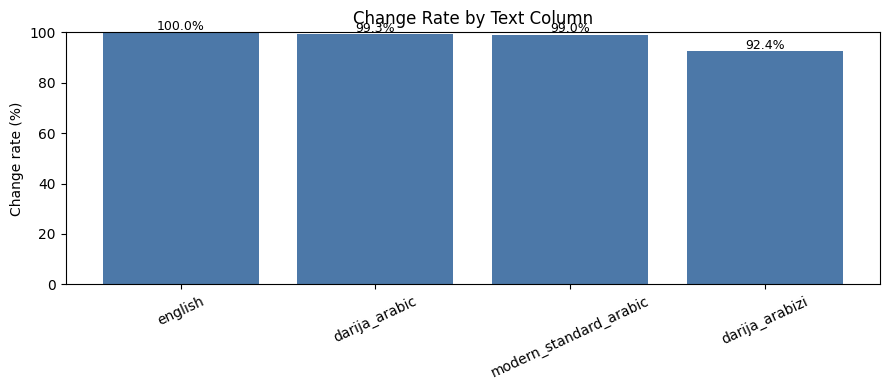

In [32]:
# Deep-dive visuals: boxplots, histogram overlays, and change-rate bars
import numpy as np
import matplotlib.pyplot as plt

if not TEXT_COLS:
    print('No common text columns to visualize.')
else:
    fig, axes = plt.subplots(len(TEXT_COLS), 2, figsize=(15, 4 * len(TEXT_COLS)))
    if len(TEXT_COLS) == 1:
        axes = np.array([axes])

    for i, col in enumerate(TEXT_COLS):
        src_len = source_df[col].fillna('').astype(str).str.len()
        cln_len = cleaned_df[col].fillna('').astype(str).str.len()

        axes[i, 0].boxplot([src_len, cln_len], tick_labels=['source', 'cleaned'], showfliers=False)
        axes[i, 0].set_title(f'Boxplot Length - {col}')
        axes[i, 0].set_ylabel('Characters')

        axes[i, 1].hist(src_len, bins=60, alpha=0.55, label='source')
        axes[i, 1].hist(cln_len, bins=60, alpha=0.55, label='cleaned')
        axes[i, 1].set_title(f'Histogram Length - {col}')
        axes[i, 1].set_xlabel('Characters')
        axes[i, 1].set_ylabel('Frequency')
        axes[i, 1].legend()

    plt.tight_layout()

if 'change_df' in globals() and isinstance(change_df, pd.DataFrame) and not change_df.empty:
    plt.figure(figsize=(9, 4))
    plot_df = change_df.sort_values('change_rate_pct', ascending=False)
    plt.bar(plot_df['column'], plot_df['change_rate_pct'], color='#4C78A8')
    plt.title('Change Rate by Text Column')
    plt.ylabel('Change rate (%)')
    plt.ylim(0, 100)
    plt.xticks(rotation=25)
    for x, y in zip(plot_df['column'], plot_df['change_rate_pct']):
        plt.text(x, y + 1, f'{y:.1f}%', ha='center', fontsize=9)
    plt.tight_layout()
else:
    print('change_df not found. Run the diff-analysis cell first.')